# Notebook 2 — SSD MobileNet V2 FPNLite 640×640 (Colab)
## Smart Sniper Spotter · Target Detection Module · Stage 2

Trains a single-class **person** detector on the merged COCO-outdoor + WiderPerson dataset (~65K train / ~7.3K val), fine-tuned from the COCO checkpoint.

**Goal:** beat the Kaggle baseline (mAP=0.278, **mAP_small=0.076**) so the model is deployable on the Pi 5 + Coral EdgeTPU. The binding metric is small-object recall (operational targets are 40–60px tall).

**Environment:** canonical conda stack — Python 3.11, TF 2.13.1 (CUDA 11.8), Keras 2, numpy 1.x. The notebook kernel stays on Colab's Python 3.12 and only orchestrates; all TF/OD-API work runs via `/usr/local/bin/python` subprocesses. No Keras-3 shims/wrappers are needed on this stack.

## 1. Environment Setup

Cell #1 swaps the runtime to a conda env via condacolab (**auto-restarts the kernel** — wait for reconnect, then run Cell #2). Cell #2 installs TF 2.13 GPU. Cell #3 installs the OD API, applies the Python-3.11 dataclass patch, installs gin-config, and verifies the **full training import chain** end-to-end.

In [1]:
# Cell #1: Install condacolab.
#
# Colab Pro currently ships Python 3.12 + TF 2.20 + numpy 2 + Keras 3 + CUDA 12.
# TF 2.13 has no wheel for Python 3.12, and its CUDA 11.8 binding doesn't
# match Colab's CUDA 12 driver layer. We can't downgrade the base interpreter
# with pip alone — we need a conda environment.
#
# condacolab installs miniforge in /usr/local, makes Python 3.10 the runtime
# default, and automatically restarts the kernel. After the restart, !pip,
# !python, !mamba all operate on the conda env.
#
# This cell ends with an automatic kernel restart. That's expected. After
# restart, the kernel disconnects briefly and reconnects, then run Cell #2.
#
# Why not try pip downgrade again: the previous attempt uninstalled TF 2.20
# without successfully installing TF 2.13 (no Python 3.12 wheel), leaving
# the kernel TF-less. condacolab swaps the Python interpreter itself, which
# is the only correct fix.

import sys
print(f"Pre-install Python: {sys.version.split()[0]}")
print(f"Pre-install platform: Colab Pro / free, T4 GPU expected")

print("\n>> Installing condacolab...")
!pip install -q condacolab

print("\n>> Running condacolab.install() — this will auto-restart the runtime.")
print("   After restart, the kernel disconnects for ~30s, then reconnects.")
print("   When it's back, proceed to Cell #2.\n")

import condacolab
condacolab.install()
# Execution stops here. The kernel restarts. Cell #2 picks up after.

Pre-install Python: 3.12.13
Pre-install platform: Colab Pro / free, T4 GPU expected

>> Installing condacolab...

>> Running condacolab.install() — this will auto-restart the runtime.
   After restart, the kernel disconnects for ~30s, then reconnects.
   When it's back, proceed to Cell #2.

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [1]:
# Cell #2: Verify condacolab installed correctly, then install TF 2.13 GPU
# into the conda env via mamba. All TF verification runs via !python
# subprocess — the notebook kernel itself stays on Colab's Python 3.12 and
# never imports TF.

import os
import subprocess

print(">> Notebook kernel Python (orchestrator):")
import sys
print(f"   {sys.version.split()[0]}  ({sys.executable})")

print("\n>> Shell `python` (training subprocess) — should be conda 3.11:")
!which python
!python --version

# Sanity check that conda env is actually usable from shell magic.
# The conda env was created by condacolab. mamba and conda live in /usr/local/bin.
result = subprocess.run(['/usr/local/bin/python', '--version'],
                        capture_output=True, text=True)
assert 'Python 3.1' in result.stdout, \
    f"Shell python is not the conda env! Got: {result.stdout!r}. " \
    "Re-run Cell #1 from a fresh runtime."
print(f"   ✓ Shell python: {result.stdout.strip()}")

print("\n>> Installing TF 2.13.1 GPU (conda-forge cuda118 build) via mamba...")
print("   This brings TF 2.13.1 + bundled CUDA 11.8 + cuDNN + Keras 2.13.")
print("   Expected ~6–8 min. The bundled CUDA tarball is ~700MB.")

# CONDA_OVERRIDE_CUDA tells the resolver to pick the cuda118 build even if
# the host driver reports CUDA 12.x. The cuda118-bundled TF brings its own
# libcudart / libcudnn in the conda env, so we don't depend on Colab's
# system CUDA libs for TF.
#
# `python=3.11` is pinned explicitly because the conda env's current Python
# is already 3.11 (per Cell #1's miniforge install). If we don't pin, the
# resolver could try to upgrade Python and break the env.

os.environ["CONDA_OVERRIDE_CUDA"] = "11.8"

# Clear the stale `python=3.12` pin that condacolab's miniforge install leaves
# behind. Without this, mamba refuses to do anything because the pin file says
# 3.12 but the env actually has 3.11. Idempotent — re-running is harmless.
print("\n>> Clearing stale conda pin (python=3.12)...")
!conda config --env --remove-key pinned_packages 2>/dev/null || true
!rm -f /usr/local/conda-meta/pinned

# Single mamba install. Important notes on what's NOT pinned here:
#   - protobuf: conda-forge's TF 2.13.1 py311 build requires libprotobuf 4.x.
#     Pinning protobuf<4 causes the solver to reject the only py311 build.
#     The OD API's *_pb2.py gencode is regenerated by protoc anyway (see
#     Cell #3), so the runtime protobuf version doesn't matter for us.
#   - keras: TF 2.13 bundles its own Keras 2.x as tf.keras; no separate pin.
#   - numpy: conda-forge picks numpy 1.26.4, which is fine.
!mamba install -y -n base -c conda-forge \
    'python=3.11' \
    'tensorflow=2.13.1=cuda118py311*' 2>&1 | tail -15

# Now verify TF in the conda env via subprocess. This is the actual test —
# we never `import tensorflow` in the kernel.
print("\n>> Verifying TF in conda env (via subprocess)...")

verify_script = r"""
import sys
import tensorflow as tf
import numpy as np
import google.protobuf
import keras

print(f"Python:     {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {keras.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"protobuf:   {google.protobuf.__version__}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")

assert tf.__version__.startswith('2.13.'), f'TF: {tf.__version__}'
assert keras.__version__.startswith('2.'), f'Keras: {keras.__version__}'
assert np.__version__.startswith('1.'), f'numpy: {np.__version__}'
# protobuf 4.x is what conda-forge ships with TF 2.13.1 py311 build; 3.x
# also fine for older builds.
assert google.protobuf.__version__.startswith(('3.', '4.')), \
    f'protobuf: {google.protobuf.__version__}'

print('\nGPUs:')
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    print(f'  {g}')
assert len(gpus) >= 1, 'No GPU visible to TF in conda env.'

# Exercise libcudart + libcudnn via a real matmul.
with tf.device('/GPU:0'):
    a = tf.random.normal([512, 512])
    b = tf.random.normal([512, 512])
    c = tf.matmul(a, b)
    _ = c.numpy()
print(f'\nGPU matmul OK: shape={c.shape}, mean={float(tf.reduce_mean(c)):.4f}')
print('\nOK')
"""

# Use -u for unbuffered output so we see progress in real time.
result = subprocess.run(['/usr/local/bin/python', '-u', '-c', verify_script],
                        capture_output=True, text=True, timeout=300)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:")
    print(result.stderr)
    raise RuntimeError(
        "TF verification in conda env failed. Read the stderr above carefully — "
        "if it mentions libcuda.so or 'No GPU', the conda env's TF can't see "
        "Colab's GPU driver. If it mentions a version mismatch, mamba installed "
        "a different TF than asked for."
    )
assert 'OK' in result.stdout, "Verify script didn't print OK marker."

print("\n✓ TF 2.13 GPU stack verified in conda env. No shims will be needed.")
print("  Subsequent training cells will use this same `!python` interpreter.")

>> Notebook kernel Python (orchestrator):
   3.12.13  (/usr/bin/python3.real)

>> Shell `python` (training subprocess) — should be conda 3.11:
/usr/local/bin/python
Python 3.11.11
   ✓ Shell python: Python 3.11.11

>> Installing TF 2.13.1 GPU (conda-forge cuda118 build) via mamba...
   This brings TF 2.13.1 + bundled CUDA 11.8 + cuDNN + Keras 2.13.
   Expected ~6–8 min. The bundled CUDA tarball is ~700MB.

>> Clearing stale conda pin (python=3.12)...



Looking for: ['python=3.11', 'tensorflow==2.13.1[build=cuda118py311*]']


Preparing transaction: - \ | / - \ done
Verifying transaction: / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \

In [2]:
# Cell #3: Install the TF2 Object Detection API into the conda env, apply the
# Python-3.11 dataclass patch, install gin-config, and verify the FULL training
# import chain end-to-end.
#
# This single cell is the entire "environment is ready" step. It folds together
# three things that were separate ad-hoc cells during debugging:
#   (a) OD API install (defensive TF/numpy pins — see invariants below),
#   (b) an AST patch that rewrites mutable @dataclass defaults under
#       official/modeling/ so tf-models-official 2.13.0 imports on Python 3.11,
#   (c) the gin-config install the OD API needs at module load via
#       optimizer_factory.
#
# Why merged: (b) can only run AFTER tf-models-official is installed, and (c) is
# a one-line dep. Keeping them here makes this a self-contained, ordered recipe.
#
# Why the verification at the end imports the TRAINING chain (not just the
# inference chain): the inference imports (config_util, model_builder, inputs)
# pass even WITHOUT the patch and gin — which is exactly why the original smoke
# test didn't catch the breakage until training started. model_main_tf2.py pulls
# in optimization_config -> optimizer_builder -> model_lib_v2, and THAT chain is
# what the patch + gin fix. We import it here so this cell proves training will
# work, instead of deferring the failure to the training cell.
#
# Critical invariants enforced here:
#   1. TF stays at 2.13.x (every pip call pins tensorflow==2.13.*), or transitive
#      deps silently upgrade TF to 2.19+ (Keras 3) and break the OD API.
#   2. numpy stays at 1.x (numpy<2), or TF's C extensions crash at import.
#   3. pyyaml>=5.1 (PyYAML 5.4.1 fails to build on 3.11; 6.x works).
#   4. MPLBACKEND='Agg' for every subprocess (Colab's inline backend leaks in
#      and crashes matplotlib in the conda env).

import os
import subprocess

# Clear Jupyter's matplotlib backend so subprocesses don't inherit it.
os.environ['MPLBACKEND'] = 'Agg'

TF_MODELS = "/content/tf_models"
PIP = "/usr/local/bin/pip"  # conda env's pip

# All OD API runtime Python deps in one pip call. The order matters:
# tensorflow + numpy + protobuf pins go FIRST so pip's resolver sees them
# as hard constraints before considering any other package's loose
# version ranges.
print(">> Installing OD API runtime Python deps (with defensive TF/numpy pins)...")
!{PIP} install -q --no-cache-dir \
    'tensorflow==2.13.*' \
    'numpy<2' \
    'protobuf<5' \
    'scipy<1.13' \
    'pyyaml>=5.1' \
    'pyparsing>=3' \
    'sacrebleu<=2.2.0' \
    'tensorflow-io==0.34.0' \
    'tensorflow-hub<0.16' \
    'tensorflow-model-optimization<0.8' \
    'pandas<2.2' \
    'avro-python3' \
    'contextlib2' \
    'tf-slim==1.1.0' \
    'pycocotools' \
    'lvis<0.5.4' \
    'pillow' \
    'lxml' \
    'Cython' \
    'matplotlib' 2>&1 | tail -5

print("\n>> Installing tf-models-official==2.13.0 (--no-deps)...")
!{PIP} install -q --no-deps --no-cache-dir \
    'tf-models-official==2.13.0' 2>&1 | tail -3

# Sanity check: confirm pip didn't clobber TF or numpy during the install.
# This is defense-in-depth — the pins above should prevent it, but if a future
# pip release loosens its resolver behavior, this assertion catches it before
# the OD API import (which would otherwise fail with a confusing Keras 3 error).
print("\n>> Sanity check: confirm TF is still 2.13.x and numpy is still 1.x...")
!/usr/local/bin/python -c "import tensorflow as tf; import numpy as np; assert tf.__version__.startswith('2.13.'), f'TF clobbered: {tf.__version__}'; assert np.__version__.startswith('1.'), f'numpy clobbered: {np.__version__}'; print(f'TF={tf.__version__} numpy={np.__version__} OK')"

# Clone tensorflow/models (the OD API source).
if not os.path.isdir(os.path.join(TF_MODELS, ".git")):
    print("\n>> Cloning tensorflow/models (shallow)...")
    !git clone --depth 1 https://github.com/tensorflow/models.git "{TF_MODELS}" 2>&1 | tail -3
else:
    print("\n>> tensorflow/models already cloned, skipping.")

# Use the conda env's protoc.
print("\n>> protoc binary in conda env:")
!which protoc
!protoc --version

os.chdir(f"{TF_MODELS}/research")
print("\n>> Compiling OD API protos...")
!protoc object_detection/protos/*.proto --python_out=. 2>&1 | tail -5

import glob
n_pb2 = len(glob.glob("object_detection/protos/*_pb2.py"))
assert n_pb2 > 10, f"Expected many *_pb2.py files; only found {n_pb2}. protoc failed."
print(f"   Generated {n_pb2} *_pb2.py files.")

# Install OD API into the conda env.
!cp object_detection/packages/tf2/setup.py .

print("\n>> Installing object_detection (--no-deps; we control versions)...")
!{PIP} install -q --no-deps . 2>&1 | tail -5

os.chdir("/content")

# Final TF/numpy sanity check before OD API import test.
print("\n>> Final TF/numpy sanity check before OD API import test...")
!/usr/local/bin/python -c "import tensorflow as tf; import numpy as np; assert tf.__version__.startswith('2.13.'), f'TF clobbered post-OD-install: {tf.__version__}'; assert np.__version__.startswith('1.'), f'numpy clobbered: {np.__version__}'; print(f'TF={tf.__version__} numpy={np.__version__} OK')"

# ---------------------------------------------------------------------------
# Python-3.11 dataclass patch: tf-models-official 2.13.0 declares mutable
# @dataclass defaults as bare Call() instances, which Python 3.11 rejects.
# Rewrite each to field(default_factory=lambda: <expr>) via AST. Must run
# AFTER tf-models-official is installed (it edits its site-packages files).
# ---------------------------------------------------------------------------
# AST-based patch: rewrite every @dataclass field with a Call default
# (mutable instance) to use field(default_factory=lambda: <expr>).
#
# Using a lambda lets us preserve the exact original default expression,
# including module-qualified names like opt_cfg.SGDConfig() and any
# constructor arguments. Simpler and more correct than trying to extract
# the class name and pass it as default_factory directly.

patch_script = r'''
import ast
import os
import sys

SITE_PKGS = "/usr/local/lib/python3.11/site-packages"

# Scan widely — any file under official/modeling that might have this pattern.
import glob
candidate_files = sorted(glob.glob(
    f"{SITE_PKGS}/official/modeling/**/*.py", recursive=True))
print(f"Scanning {len(candidate_files)} files under official/modeling...")


class MutableDefaultRewriter(ast.NodeTransformer):
    """Rewrite `name: T = Call(...)` to `name: T = field(default_factory=lambda: Call(...))`
    inside @dataclass classes."""

    def __init__(self):
        self.in_dataclass = False
        self.rewrites = 0
        self.needs_field_import = False

    def visit_ClassDef(self, node):
        # Is this class decorated with @dataclasses.dataclass or @dataclass?
        is_dc = False
        for dec in node.decorator_list:
            if isinstance(dec, ast.Attribute) and dec.attr == 'dataclass':
                is_dc = True
            elif isinstance(dec, ast.Name) and dec.id == 'dataclass':
                is_dc = True
            elif isinstance(dec, ast.Call):
                # @dataclass(...) form
                f = dec.func
                if isinstance(f, ast.Attribute) and f.attr == 'dataclass':
                    is_dc = True
                elif isinstance(f, ast.Name) and f.id == 'dataclass':
                    is_dc = True

        if not is_dc:
            return self.generic_visit(node)

        prev = self.in_dataclass
        self.in_dataclass = True
        node = self.generic_visit(node)
        self.in_dataclass = prev
        return node

    def visit_AnnAssign(self, node):
        # `target: annotation = value`
        if not self.in_dataclass or node.value is None:
            return node
        # Only rewrite Call defaults (those are the mutable instances).
        # Skip ast.Constant (None, numbers, strings) and ast.Name (references).
        if not isinstance(node.value, ast.Call):
            return node
        # Replace `= EXPR` with `= dataclasses.field(default_factory=lambda: EXPR)`
        original_default = node.value
        new_default = ast.Call(
            func=ast.Attribute(
                value=ast.Name(id='dataclasses', ctx=ast.Load()),
                attr='field', ctx=ast.Load()),
            args=[],
            keywords=[
                ast.keyword(
                    arg='default_factory',
                    value=ast.Lambda(
                        args=ast.arguments(
                            posonlyargs=[], args=[], kwonlyargs=[],
                            kw_defaults=[], defaults=[]),
                        body=original_default))
            ])
        ast.copy_location(new_default, original_default)
        node.value = new_default
        self.rewrites += 1
        return node


total_files_patched = 0
total_rewrites = 0
for path in candidate_files:
    try:
        with open(path) as f:
            src = f.read()
        if '@dataclasses.dataclass' not in src and '@dataclass' not in src:
            continue
        tree = ast.parse(src)
        rw = MutableDefaultRewriter()
        new_tree = rw.visit(tree)
        if rw.rewrites == 0:
            continue
        ast.fix_missing_locations(new_tree)
        new_src = ast.unparse(new_tree)
        # Sanity check: new source must parse.
        ast.parse(new_src)
        with open(path, 'w') as f:
            f.write(new_src)
        rel = os.path.relpath(path, SITE_PKGS)
        print(f"  {rel}: {rw.rewrites} fields rewritten")
        total_files_patched += 1
        total_rewrites += rw.rewrites
    except SyntaxError as e:
        print(f"  SKIP (parse error): {path}: {e}")
    except Exception as e:
        print(f"  SKIP (other error): {path}: {e}")

print(f"\nTotal: {total_rewrites} fields rewritten across {total_files_patched} files")
'''

import subprocess
result = subprocess.run(['/usr/local/bin/python', '-c', patch_script],
                        capture_output=True, text=True, timeout=120,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])

# ---------------------------------------------------------------------------
# gin-config: the OD API imports it at module load (optimizer_factory). It's a
# tf-models-official dep we installed --no-deps, so it's missing. Pin TF/numpy
# defensively here too — a bare `pip install gin-config` can drag TF along.
# ---------------------------------------------------------------------------
print("\n>> Installing gin-config (with defensive TF/numpy pins)...")
!{PIP} install -q --no-cache-dir 'tensorflow==2.13.*' 'numpy<2' 'gin-config' 2>&1 | tail -3

# ---------------------------------------------------------------------------
# Final verification: import the FULL training chain in the conda env via
# subprocess and capture model_main_tf2.py's path for the training cells.
# ---------------------------------------------------------------------------
print("\n>> Verifying full training import chain (via subprocess)...")

verify_od_script = r"""
import os

# Inference chain (passes even without the patch/gin — not a sufficient test).
from object_detection.utils import config_util
from object_detection.utils import label_map_util
from object_detection.builders import model_builder
from object_detection import inputs
print('inference chain (config_util, model_builder, inputs) — OK')

# SSD MobileNet V2 FPN keras feature extractor (NB2's backbone).
from object_detection.models import ssd_mobilenet_v2_fpn_keras_feature_extractor as _fe
assert hasattr(_fe, 'SSDMobileNetV2FpnKerasFeatureExtractor'), \
    'SSD MobileNet V2 FPN keras feature extractor class missing.'
print('SSD MobileNet V2 FPN keras feature extractor — OK')

# TRAINING chain: this is what the AST patch + gin fix. If the patch didn't
# take or gin is missing, one of these three imports raises.
from official.modeling.optimization.configs import optimization_config
print('optimization_config — OK (dataclass patch took)')
from object_detection.builders import optimizer_builder
print('optimizer_builder — OK')
from object_detection import model_lib_v2
print('model_lib_v2 — OK (training chain importable)')

# Locate model_main_tf2.py and print it so the kernel can capture the path.
import object_detection as _od_pkg
od_root = os.path.dirname(_od_pkg.__file__)
model_main = os.path.join(od_root, 'model_main_tf2.py')
assert os.path.exists(model_main), f'model_main_tf2.py missing at {model_main}'
print(f'MODEL_MAIN={model_main}')
"""

result = subprocess.run(['/usr/local/bin/python', '-c', verify_od_script],
                        capture_output=True, text=True, timeout=180,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
print(result.stdout)
if result.returncode != 0:
    print("STDERR:")
    print(result.stderr[-2500:])
    raise RuntimeError(
        "Training-chain verification failed. If it broke on "
        "'optimization_config', the AST patch didn't take; if on a gin import, "
        "the gin install didn't land. See stderr above.")

# Capture MODEL_MAIN for the training/eval cells.
MODEL_MAIN = None
for line in result.stdout.splitlines():
    if line.startswith('MODEL_MAIN='):
        MODEL_MAIN = line.split('=', 1)[1].strip()
        break
assert MODEL_MAIN and os.path.exists(MODEL_MAIN), \
    f"Could not extract MODEL_MAIN from subprocess output. Got: {MODEL_MAIN}"

print(f"\n✓ Environment ready. Full training chain importable on the conda stack.")
print(f"  Captured for later cells: MODEL_MAIN = {MODEL_MAIN}")

>> Installing OD API runtime Python deps (with defensive TF/numpy pins)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 189.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 307.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 415.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 217.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.8/799.8 kB 469.7 MB/s eta 0:00:00

>> Installing tf-models-official==2.13.0 (--no-deps)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 14.7 MB/s eta 0:00:00

>> Sanity check: confirm TF is still 2.13.x and numpy is still 1.x...
2026-05-25 23:08:50.490435: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate com

## 2. Fetch Training Data (Kaggle Dataset)

Cell #4 installs the kaggle CLI and prompts for `kaggle.json`. Cell #5 downloads `giladfaibish/smart-spotter-tfrecords-v1` (~10GB) and exports `TRAIN_PATTERN`, `VAL_PATTERN`, `LABEL_MAP_PATH`.

In [3]:
# Cell #B1: Install kaggle CLI in the conda env and upload kaggle.json.
#
# We install the kaggle CLI into the *conda env* (which has TF 2.13) so that
# any TF code can read the downloaded TFRecords without crossing the
# kernel/subprocess boundary unnecessarily. The kaggle CLI itself is pure
# Python — install is fast (~10s).
#
# kaggle.json must contain {"username": "...", "key": "..."} — your Kaggle
# Legacy API credentials. Upload it via the Colab file picker; we'll move
# it to ~/.kaggle/ where the CLI looks.

import os
import json
from pathlib import Path

PIP = "/usr/local/bin/pip"
print(">> Installing kaggle CLI in conda env...")
!{PIP} install -q --no-cache-dir kaggle 2>&1 | tail -3

# Upload kaggle.json. Colab's files.upload() returns a dict of {filename: bytes}.
from google.colab import files
print("\n>> Please select your kaggle.json file when the file picker opens...")
uploaded = files.upload()

assert "kaggle.json" in uploaded, (
    "Expected a file named exactly 'kaggle.json'. Got: " + str(list(uploaded.keys())))

# Place it where the kaggle CLI expects it and set 0600 permissions
# (kaggle CLI refuses to read it otherwise).
kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)
kaggle_json = kaggle_dir / "kaggle.json"
kaggle_json.write_bytes(uploaded["kaggle.json"])
kaggle_json.chmod(0o600)

# Verify the credentials parse cleanly.
creds = json.loads(kaggle_json.read_text())
assert "username" in creds and "key" in creds, \
    "kaggle.json must have 'username' and 'key' fields"
print(f"   ✓ Credentials installed for username: {creds['username']}")

# Verify the CLI can actually authenticate.
!kaggle --version
print("\n>> Listing your private datasets (auth check)...")
!kaggle datasets list --mine 2>&1 | head -10

>> Installing kaggle CLI in conda env...
tf-models-official 2.13.0 requires tensorflow-datasets, which is not installed.
tf-models-official 2.13.0 requires tensorflow-text~=2.13.0, which is not installed.
tf-models-official 2.13.0 requires pyyaml<6.0,>=5.1, but you have pyyaml 6.0.3 which is incompatible.

>> Please select your kaggle.json file when the file picker opens...


Saving kaggle.json to kaggle.json
   ✓ Credentials installed for username: giladfaibish
Kaggle CLI 2.1.2

>> Listing your private datasets (auth check)...
ref                                      title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------  -------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
giladfaibish/smart-spotter-tfrecords-v1  Smart Sniper Spotter — Stage 2 TFRecords v1  11206535924  2026-05-18 17:55:34.820000              1          0  0.5              


In [4]:
# Cell #B2: Download the TFRecord dataset and resolve paths for training.
#
# After this cell runs, the rest of the training notebook can use:
#   - TRAIN_PATTERN  → "/content/tfrecords/train-*.tfrecord*"
#   - VAL_PATTERN    → "/content/tfrecords/val-*.tfrecord*"
#   - LABEL_MAP_PATH → "/content/tfrecords/label_map.pbtxt"
#
# in pipeline.config and elsewhere.

import os
import glob
import subprocess

DATASET_SLUG = "giladfaibish/smart-spotter-tfrecords-v1"
DOWNLOAD_DIR = "/content/tfrecords_download"
TFRECORD_DIR = "/content/tfrecords"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)
os.makedirs(TFRECORD_DIR, exist_ok=True)

# `--unzip` extracts the dataset zip inline. `--force` re-downloads even if
# the zip is already in the cache, which we want when iterating in case the
# dataset got a new version.
print(f">> Downloading {DATASET_SLUG} (~10GB)...")
!kaggle datasets download -d {DATASET_SLUG} -p {DOWNLOAD_DIR} --unzip 2>&1 | tail -20

# Kaggle's --unzip puts everything at the top level of DOWNLOAD_DIR.
# Move TFRecords + label_map to TFRECORD_DIR for clean paths.
import shutil

# TFRecords — could be under DOWNLOAD_DIR/tfrecords/ (matching publishing
# layout) or directly under DOWNLOAD_DIR (if Kaggle flattened the structure).
candidate_dirs = [
    os.path.join(DOWNLOAD_DIR, "tfrecords"),
    DOWNLOAD_DIR,
]
src_tfrecord_dir = None
for d in candidate_dirs:
    if glob.glob(os.path.join(d, "train-*.tfrecord*")):
        src_tfrecord_dir = d
        break
assert src_tfrecord_dir, (
    f"No train-*.tfrecord files found under {DOWNLOAD_DIR}. "
    f"Contents: {os.listdir(DOWNLOAD_DIR)}")

print(f"\n>> Found TFRecords in {src_tfrecord_dir}")
for src in glob.glob(os.path.join(src_tfrecord_dir, "*.tfrecord*")):
    dst = os.path.join(TFRECORD_DIR, os.path.basename(src))
    if src != dst:
        shutil.move(src, dst)

# label_map.pbtxt
label_map_candidates = (
    glob.glob(os.path.join(DOWNLOAD_DIR, "label_map.pbtxt")) +
    glob.glob(os.path.join(DOWNLOAD_DIR, "**/label_map.pbtxt"), recursive=True))
assert label_map_candidates, f"label_map.pbtxt not found in {DOWNLOAD_DIR}"
dst_label_map = os.path.join(TFRECORD_DIR, "label_map.pbtxt")
if label_map_candidates[0] != dst_label_map:
    shutil.copy2(label_map_candidates[0], dst_label_map)

# Optional metadata.
md_candidates = glob.glob(os.path.join(DOWNLOAD_DIR, "**/dataset_metadata.json"),
                          recursive=True)
if md_candidates:
    shutil.copy2(md_candidates[0], os.path.join(TFRECORD_DIR, "dataset_metadata.json"))

# Final resolution: paths the rest of the notebook will consume.
TRAIN_PATTERN = os.path.join(TFRECORD_DIR, "train-*.tfrecord*")
VAL_PATTERN = os.path.join(TFRECORD_DIR, "val-*.tfrecord*")
LABEL_MAP_PATH = os.path.join(TFRECORD_DIR, "label_map.pbtxt")

train_shards = sorted(glob.glob(TRAIN_PATTERN))
val_shards = sorted(glob.glob(VAL_PATTERN))
total_bytes = sum(os.path.getsize(p) for p in train_shards + val_shards)

print(f"\n>> TFRecord layout in {TFRECORD_DIR}:")
print(f"   Train shards: {len(train_shards)}")
print(f"   Val shards:   {len(val_shards)}")
print(f"   Total size:   {total_bytes/1e9:.2f} GB")
print(f"   Label map:    {LABEL_MAP_PATH} (exists={os.path.exists(LABEL_MAP_PATH)})")

assert len(train_shards) == 16, f"Expected 16 train shards, got {len(train_shards)}"
assert len(val_shards) == 4, f"Expected 4 val shards, got {len(val_shards)}"
assert os.path.exists(LABEL_MAP_PATH), "label_map.pbtxt is missing"

# Read-back sanity check via subprocess (TF lives in conda env, not the kernel).
print("\n>> Validating TFRecords by reading first example (subprocess)...")
validate_script = f"""
import glob, tensorflow as tf

for pattern, name in [({TRAIN_PATTERN!r}, 'train'), ({VAL_PATTERN!r}, 'val')]:
    paths = sorted(glob.glob(pattern))
    for raw in tf.data.TFRecordDataset(paths).take(1):
        ex = tf.train.Example()
        ex.ParseFromString(raw.numpy())
        feat = ex.features.feature
        fname = feat['image/filename'].bytes_list.value[0].decode()
        w = feat['image/width'].int64_list.value[0]
        h = feat['image/height'].int64_list.value[0]
        nb = len(feat['image/object/bbox/xmin'].float_list.value)
        print(f'{{name}} first example: {{fname}} {{w}}x{{h}} {{nb}} box(es)')
"""
result = subprocess.run(['/usr/local/bin/python', '-c', validate_script],
                        capture_output=True, text=True, timeout=120,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-1500:])
    raise RuntimeError("TFRecord validation failed.")

# Clean up the download dir to free disk space.
shutil.rmtree(DOWNLOAD_DIR, ignore_errors=True)
print(f"\n✓ TFRecords ready at {TFRECORD_DIR}")
print(f"   Constants exported: TRAIN_PATTERN, VAL_PATTERN, LABEL_MAP_PATH")

>> Downloading giladfaibish/smart-spotter-tfrecords-v1 (~10GB)...
Dataset URL: https://www.kaggle.com/datasets/giladfaibish/smart-spotter-tfrecords-v1
License(s): other
100%|██████████| 10.4G/10.4G [02:16<00:00, 82.0MB/s]


>> Found TFRecords in /content/tfrecords_download

>> TFRecord layout in /content/tfrecords:
   Train shards: 16
   Val shards:   4
   Total size:   11.30 GB
   Label map:    /content/tfrecords/label_map.pbtxt (exists=True)

>> Validating TFRecords by reading first example (subprocess)...
train first example: 000000135749.jpg 375x500 9 box(es)
val first example: 000000279073.jpg 640x425 4 box(es)


✓ TFRecords ready at /content/tfrecords
   Constants exported: TRAIN_PATTERN, VAL_PATTERN, LABEL_MAP_PATH


## 3. Pretrained Checkpoint

In [5]:
# Cell #6: Download the COCO-pretrained SSD MobileNet V2 FPNLite 640x640
# checkpoint (TF2 Model Zoo, 20200711 release). We fine-tune from this with
# fine_tune_checkpoint_type: "detection", so the whole detector (backbone +
# FPN + box/class heads) is restored by name and adapted to our 1-class
# person task. All work lives under /content (local SSD — fast); the final
# checkpoint is copied to Drive at the end (Cell #17).

import os

WORK_DIR = "/content/nb2_run"
MODEL_DIR = os.path.join(WORK_DIR, "pretrained_model")
TRAIN_DIR = os.path.join(WORK_DIR, "training_output")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(TRAIN_DIR, exist_ok=True)

MODEL_URL = "http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8.tar.gz"
MODEL_TAR = os.path.join(WORK_DIR, "ssd_mobilenet_v2_fpnlite_640x640.tar.gz")
MODEL_NAME = "ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8"
PRETRAINED_CKPT_DIR = os.path.join(MODEL_DIR, MODEL_NAME)

if os.path.exists(os.path.join(PRETRAINED_CKPT_DIR, "checkpoint")):
    print(f"Pretrained model already present at {PRETRAINED_CKPT_DIR}")
else:
    print("Downloading SSD MobileNet V2 FPNLite 640x640 (~20MB)...")
    !wget -q --show-progress -O "{MODEL_TAR}" "{MODEL_URL}"
    print("Extracting...")
    !tar -xf "{MODEL_TAR}" -C "{MODEL_DIR}"
    os.remove(MODEL_TAR)
    print("Done.")

# Checkpoint prefix we fine-tune from (the zoo ships ckpt-0).
FINE_TUNE_CKPT = os.path.join(PRETRAINED_CKPT_DIR, "checkpoint", "ckpt-0")
print(f"\nFine-tune checkpoint prefix: {FINE_TUNE_CKPT}")
!ls -la "{PRETRAINED_CKPT_DIR}/checkpoint/"

/content/nb2_run/ss 100%[===================>]  19.57M  --.-KB/s    in 0.1s    
Extracting...
Done.

Fine-tune checkpoint prefix: /content/nb2_run/pretrained_model/ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8/checkpoint/ckpt-0
total 10524
drwxr-x--- 2 345018 89939     4096 Jul 10  2020 .
drwxr-x--- 4 345018 89939     4096 Jul 11  2020 ..
-rw-r----- 1 345018 89939      166 Jul 10  2020 checkpoint
-rw-r----- 1 345018 89939 10752177 Jul 10  2020 ckpt-0.data-00000-of-00001
-rw-r----- 1 345018 89939     6872 Jul 10  2020 ckpt-0.index


## 4. Configure Training Pipeline

Cell #7 sets hyperparameters; Cell #8 writes the improved `pipeline.config` (large-scale-jitter augmentation, denser anchors, raised NMS cap, single-GPU `replicas_to_aggregate`, 50K-step stretched cosine schedule).

In [6]:
# Cell #7: Training hyperparameters.
#
# These differ from the Kaggle NB2 run on purpose — the goal is to beat
# Kaggle's mAP_small=0.076, not reproduce it. Rationale per knob:
#   - NUM_STEPS 50000 (was 30000): the large-scale-jitter augmentation in the
#     pipeline (Cell #8) makes each step harder, so the useful-training window
#     extends past Kaggle's ~15K convergence point. Cosine decay is stretched
#     over the full 50K (not 30K steps re-used), with warmup 2000.
#   - PHASE1_STEPS 1000: a cheap early-kill gate (Cell #10/#11) to confirm
#     restoration isn't broken before committing the full ~5h run.
#   - CHECKPOINT_EVERY_N 1000: frequent enough that a Colab disconnect resumes
#     with little lost work (CheckpointManager keeps the last 7).
#   - BASE_LR 0.01 / WARMUP_LR 0.001: proven stable at batch 8 on Kaggle; the
#     Kaggle weakness was underfitting small objects, not LR instability.

BATCH_SIZE = 8           # Fits 640x640 on a single T4 (16GB).
NUM_STEPS = 50000        # Stretched schedule (see rationale above).
WARMUP_STEPS = 2000
PHASE1_STEPS = 1000      # Early-kill gate checkpoint.
CHECKPOINT_EVERY_N = 1000
NUM_CLASSES = 1          # person only

BASE_LEARNING_RATE = 0.01
WARMUP_LEARNING_RATE = 0.001

# TFRecord patterns + label map come from the fetch cell (Cell #5).
# TRAIN_PATTERN, VAL_PATTERN, LABEL_MAP_PATH are already defined.
assert 'TRAIN_PATTERN' in dir() and 'VAL_PATTERN' in dir() and 'LABEL_MAP_PATH' in dir(), \
    "Run the fetch cells (Cell #4, #5) first — TRAIN_PATTERN/VAL_PATTERN/LABEL_MAP_PATH missing."

print(f"Batch size:        {BATCH_SIZE}")
print(f"Training steps:    {NUM_STEPS}  (warmup {WARMUP_STEPS})")
print(f"Phase-1 gate at:   {PHASE1_STEPS} steps")
print(f"Checkpoint every:  {CHECKPOINT_EVERY_N} steps")
print(f"Base / warmup LR:  {BASE_LEARNING_RATE} / {WARMUP_LEARNING_RATE}")
print(f"Train pattern:     {TRAIN_PATTERN}")
print(f"Val pattern:       {VAL_PATTERN}")
print(f"Label map:         {LABEL_MAP_PATH}")
print(f"Fine-tune from:    {FINE_TUNE_CKPT}")

Batch size:        8
Training steps:    50000  (warmup 2000)
Phase-1 gate at:   1000 steps
Checkpoint every:  1000 steps
Base / warmup LR:  0.01 / 0.001
Train pattern:     /content/tfrecords/train-*.tfrecord*
Val pattern:       /content/tfrecords/val-*.tfrecord*
Label map:         /content/tfrecords/label_map.pbtxt
Fine-tune from:    /content/nb2_run/pretrained_model/ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8/checkpoint/ckpt-0


In [7]:
# Cell #8: Write the improved pipeline.config.
#
# Base architecture is the zoo's SSD MobileNet V2 FPNLite 640x640, modified
# for single-class person detection. Five changes vs the Kaggle NB2 config,
# every one aimed at small-object (40-60px-height) recall — our deployment-
# critical metric:
#
#   1. replicas_to_aggregate: 8 -> 1
#      Kaggle inherited the TPU-pod value; on a single T4 it's just wrong.
#
#   2. Augmentation overhaul -> large-scale jitter.
#      Dropped Kaggle's redundant/conflicting crops (it had BOTH
#      random_crop_image AND ssd_random_crop, and ssd_random_crop biases
#      toward larger objects). Replaced with random_scale_crop_and_pad_to_square
#      (scale_min 0.1, scale_max 2.0) — the exact large-scale-jitter the
#      EfficientDet zoo configs use. scale<1 zooms out and MANUFACTURES small
#      instances, which is precisely our weak spot. Kept the mild photometric
#      augs (brightness/contrast/rgb_to_gray) — they suit the daytime+dusk/dawn
#      domain. (Note: random_scale_crop_and_pad_to_square is the correct op
#      name; an earlier note called it random_square_crop_by_scale, which is a
#      different CenterNet-style crop — this is the LSJ one used by EffDet.)
#
#   3. scales_per_octave: 2 -> 3
#      Denser anchors in the 40-60px band -> higher small-object recall.
#
#   4. NMS detection cap: 20 -> 100 (per-class and total)
#      WiderPerson frames are crowded; a cap of 20 artificially suppresses the
#      recall measured by mAP. We re-cap to ~15-20 at EXPORT for deployment
#      latency (Notebook 4); this only affects the eval number here.
#
#   5. num_steps / schedule: 30000 -> 50000, stretched cosine decay.
#
# Kept as-is: fixed_shape_resizer 640x640, focal gamma 2.0 alpha 0.25,
# freeze_batchnorm: false (lets BN adapt to the domain shift),
# fine_tune_checkpoint_type: "detection".

import os

PIPELINE_CONFIG_PATH = os.path.join(WORK_DIR, "pipeline.config")

pipeline_config = f"""
model {{
  ssd {{
    num_classes: {NUM_CLASSES}
    image_resizer {{
      fixed_shape_resizer {{
        height: 640
        width: 640
      }}
    }}
    feature_extractor {{
      type: "ssd_mobilenet_v2_fpn_keras"
      depth_multiplier: 1.0
      min_depth: 16
      conv_hyperparams {{
        regularizer {{
          l2_regularizer {{
            weight: 0.00004
          }}
        }}
        initializer {{
          random_normal_initializer {{
            mean: 0.0
            stddev: 0.01
          }}
        }}
        activation: RELU_6
        batch_norm {{
          decay: 0.997
          scale: true
          epsilon: 0.001
        }}
      }}
      use_depthwise: true
      override_base_feature_extractor_hyperparams: true
      fpn {{
        min_level: 3
        max_level: 7
        additional_layer_depth: 128
      }}
    }}
    box_coder {{
      faster_rcnn_box_coder {{
        y_scale: 10.0
        x_scale: 10.0
        height_scale: 5.0
        width_scale: 5.0
      }}
    }}
    matcher {{
      argmax_matcher {{
        matched_threshold: 0.5
        unmatched_threshold: 0.5
        ignore_thresholds: false
        negatives_lower_than_unmatched: true
        force_match_for_each_row: true
        use_matmul_gather: true
      }}
    }}
    similarity_calculator {{
      iou_similarity {{
      }}
    }}
    box_predictor {{
      weight_shared_convolutional_box_predictor {{
        conv_hyperparams {{
          regularizer {{
            l2_regularizer {{
              weight: 0.00004
            }}
          }}
          initializer {{
            random_normal_initializer {{
              mean: 0.0
              stddev: 0.01
            }}
          }}
          activation: RELU_6
          batch_norm {{
            decay: 0.997
            scale: true
            epsilon: 0.001
          }}
        }}
        depth: 128
        num_layers_before_predictor: 4
        kernel_size: 3
        class_prediction_bias_init: -4.6
      }}
    }}
    anchor_generator {{
      multiscale_anchor_generator {{
        min_level: 3
        max_level: 7
        anchor_scale: 4.0
        aspect_ratios: 1.0
        aspect_ratios: 2.0
        aspect_ratios: 0.5
        scales_per_octave: 3
      }}
    }}
    post_processing {{
      batch_non_max_suppression {{
        score_threshold: 0.01
        iou_threshold: 0.6
        max_detections_per_class: 100
        max_total_detections: 100
        use_static_shapes: false
      }}
      score_converter: SIGMOID
    }}
    normalize_loss_by_num_matches: true
    loss {{
      localization_loss {{
        weighted_smooth_l1 {{
        }}
      }}
      classification_loss {{
        weighted_sigmoid_focal {{
          gamma: 2.0
          alpha: 0.25
        }}
      }}
      classification_weight: 1.0
      localization_weight: 1.0
    }}
    encode_background_as_zeros: true
    normalize_loc_loss_by_codesize: true
    inplace_batchnorm_update: true
    freeze_batchnorm: false
  }}
}}

train_config {{
  batch_size: {BATCH_SIZE}
  data_augmentation_options {{
    random_horizontal_flip {{
    }}
  }}
  data_augmentation_options {{
    random_scale_crop_and_pad_to_square {{
      output_size: 640
      scale_min: 0.1
      scale_max: 2.0
    }}
  }}
  data_augmentation_options {{
    random_adjust_brightness {{
      max_delta: 0.15
    }}
  }}
  data_augmentation_options {{
    random_adjust_contrast {{
      min_delta: 0.8
      max_delta: 1.2
    }}
  }}
  data_augmentation_options {{
    random_rgb_to_gray {{
      probability: 0.1
    }}
  }}
  sync_replicas: true
  optimizer {{
    momentum_optimizer {{
      learning_rate {{
        cosine_decay_learning_rate {{
          learning_rate_base: {BASE_LEARNING_RATE}
          total_steps: {NUM_STEPS}
          warmup_learning_rate: {WARMUP_LEARNING_RATE}
          warmup_steps: {WARMUP_STEPS}
        }}
      }}
      momentum_optimizer_value: 0.9
    }}
    use_moving_average: false
  }}
  fine_tune_checkpoint: "{FINE_TUNE_CKPT}"
  num_steps: {NUM_STEPS}
  startup_delay_steps: 0.0
  replicas_to_aggregate: 1
  max_number_of_boxes: 100
  unpad_groundtruth_tensors: false
  fine_tune_checkpoint_type: "detection"
  fine_tune_checkpoint_version: V2
}}

train_input_reader {{
  label_map_path: "{LABEL_MAP_PATH}"
  tf_record_input_reader {{
    input_path: "{TRAIN_PATTERN}"
  }}
}}

eval_config {{
  metrics_set: "coco_detection_metrics"
  use_moving_averages: false
  batch_size: 1
}}

eval_input_reader {{
  label_map_path: "{LABEL_MAP_PATH}"
  shuffle: false
  num_epochs: 1
  tf_record_input_reader {{
    input_path: "{VAL_PATTERN}"
  }}
}}
"""

with open(PIPELINE_CONFIG_PATH, "w") as f:
    f.write(pipeline_config)
print(f"Pipeline config written to: {PIPELINE_CONFIG_PATH} ({len(pipeline_config)} chars)")

# Re-parse via subprocess (config_util needs TF, which lives in the conda env).
import subprocess
verify_cfg = f"""
from object_detection.utils import config_util
c = config_util.get_configs_from_pipeline_file({PIPELINE_CONFIG_PATH!r})
m, t = c['model'].ssd, c['train_config']
print(f"  Model:          {{c['model'].WhichOneof('model')}}")
print(f"  Feature ext.:   {{m.feature_extractor.type}}")
print(f"  Num classes:    {{m.num_classes}}")
print(f"  scales/octave:  {{m.anchor_generator.multiscale_anchor_generator.scales_per_octave}}")
print(f"  NMS max total:  {{m.post_processing.batch_non_max_suppression.max_total_detections}}")
print(f"  Batch size:     {{t.batch_size}}")
print(f"  Num steps:      {{t.num_steps}}")
print(f"  replicas_aggr:  {{t.replicas_to_aggregate}}")
print(f"  Augmentations:  {{len(t.data_augmentation_options)}}")
print(f"  Fine-tune type: {{t.fine_tune_checkpoint_type}}")
"""
result = subprocess.run(['/usr/local/bin/python', '-c', verify_cfg],
                        capture_output=True, text=True, timeout=120,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
print(result.stdout)
if result.returncode != 0:
    print("STDERR:")
    print(result.stderr[-2000:])
    raise RuntimeError("Pipeline config did not parse cleanly.")

Pipeline config written to: /content/nb2_run/pipeline.config (4603 chars)
  Model:          ssd
  Feature ext.:   ssd_mobilenet_v2_fpn_keras
  Num classes:    1
  scales/octave:  3
  NMS max total:  100
  Batch size:     8
  Num steps:      50000
  replicas_aggr:  1
  Augmentations:  5
  Fine-tune type: detection



## 5. Pre-flight Restoration Check

In [8]:
# Cell #9: Pre-flight restoration check (via subprocess).
#
# Necessary condition for "the architecture isn't broken": every variable in
# the restore dict must match a tensor in the COCO checkpoint. This catches
# name/shape mismatches before we burn any training time. The sufficient
# condition (loss actually drops) is the early-kill gate in Cell #10/#11.

import os, subprocess

preflight_script = f"""
import sys
import tensorflow as tf
from object_detection.builders import model_builder
from object_detection.utils import config_util

cfg = config_util.get_configs_from_pipeline_file({PIPELINE_CONFIG_PATH!r})
detection_model = model_builder.build(model_config=cfg["model"], is_training=True)

# Force variable creation with one forward pass at the real input size.
dummy = tf.zeros([1, 640, 640, 3], dtype=tf.float32)
images, shapes = detection_model.preprocess(dummy)
_ = detection_model.predict(images, shapes)
print(f"Model built. Trainable variables: {{len(detection_model.trainable_variables)}}")

# Build the restore dict the OD-API way and check it against the checkpoint.
restore_dict = detection_model.restore_from_objects(fine_tune_checkpoint_type="detection")
print(f"Restore dict keys: {{list(restore_dict.keys())}}")

ckpt = tf.train.Checkpoint(**restore_dict)
status = ckpt.restore({FINE_TUNE_CKPT!r})
status.expect_partial()
try:
    status.assert_existing_objects_matched()
    print("PREFLIGHT_RESULT=PASS")
except Exception as e:
    print(f"PREFLIGHT_ERROR: {{e}}")
    print("PREFLIGHT_RESULT=FAIL")
    sys.exit(1)
"""

print(">> Running pre-flight restore check in conda env...")
result = subprocess.run(['/usr/local/bin/python', '-u', '-c', preflight_script],
                        capture_output=True, text=True, timeout=300,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
print(result.stdout)
if result.returncode != 0:
    print("STDERR (last 2000 chars):")
    print(result.stderr[-2000:])

PREFLIGHT_PASSED = 'PREFLIGHT_RESULT=PASS' in result.stdout
if PREFLIGHT_PASSED:
    print("\n✓ PRE-FLIGHT OK: every restore-dict variable matched a checkpoint tensor.")
    print("  (Necessary condition met. The loss gate in Cell #11 is the sufficient one.)")
else:
    print("\n✗ PRE-FLIGHT FAILED: restoration cannot proceed cleanly. Do not train.")

>> Running pre-flight restore check in conda env...
Model built. Trainable variables: 270
Restore dict keys: ['model']
PREFLIGHT_RESULT=PASS


✓ PRE-FLIGHT OK: every restore-dict variable matched a checkpoint tensor.
  (Necessary condition met. The loss gate in Cell #11 is the sufficient one.)


## 6. Train the Model

Two phases: a cheap 1,000-step early-kill gate, then the full resume to 50K. Re-running Cell #12 after a disconnect resumes from the latest checkpoint.

In [9]:
# Cell #10: Phase 1 training (steps 0 -> PHASE1_STEPS) + early-kill gate.
#
# Why subprocess: model_main_tf2 calls absl.app.run(), which can only run once
# per process. Running it via !python keeps the notebook kernel clean.
# Why NO wrapper script: on the canonical TF 2.13 / Keras 2 / numpy 1.x conda
# stack, no shims are needed (the Kaggle wrappers existed only for Kaggle's
# TF 2.19 / Keras 3). We invoke model_main_tf2.py directly.
# Why two phases: trip a cheap gate at PHASE1_STEPS before committing ~5h.

import os
assert PREFLIGHT_PASSED, "Pre-flight (Cell #9) didn't pass. Don't run training."
assert os.path.exists(MODEL_MAIN), f"MODEL_MAIN missing: {MODEL_MAIN}. Re-run Cell #3."

print(f">> Phase 1: training {PHASE1_STEPS} steps...")
print(f"   model_main_tf2.py: {MODEL_MAIN}")
print(f"   pipeline:          {PIPELINE_CONFIG_PATH}")
print(f"   output:            {TRAIN_DIR}")
print("=" * 60)

!/usr/local/bin/python "{MODEL_MAIN}" \
    --pipeline_config_path="{PIPELINE_CONFIG_PATH}" \
    --model_dir="{TRAIN_DIR}" \
    --num_train_steps={PHASE1_STEPS} \
    --checkpoint_every_n={CHECKPOINT_EVERY_N} \
    --alsologtostderr 2>&1 | tail -120

print("=" * 60)
print(">> Phase 1 done. Run Cell #11 to parse the loss curve and apply the gate.")

>> Phase 1: training 1000 steps...
   model_main_tf2.py: /usr/local/lib/python3.11/site-packages/object_detection/model_main_tf2.py
   pipeline:          /content/nb2_run/pipeline.config
   output:            /content/nb2_run/training_output
 'Loss/total_loss': 0.93030906,
 'learning_rate': 0.00145}
I0525 23:18:52.907372 134538970318656 model_lib_v2.py:708] {'Loss/classification_loss': 0.35336936,
 'Loss/localization_loss': 0.4230153,
 'Loss/regularization_loss': 0.15392439,
 'Loss/total_loss': 0.93030906,
 'learning_rate': 0.00145}
INFO:tensorflow:Step 200 per-step time 0.536s
I0525 23:19:46.513040 134538970318656 model_lib_v2.py:705] Step 200 per-step time 0.536s
INFO:tensorflow:{'Loss/classification_loss': 0.3361237,
 'Loss/localization_loss': 0.3784115,
 'Loss/regularization_loss': 0.15391989,
 'Loss/total_loss': 0.8684551,
 'learning_rate': 0.0019}
I0525 23:19:46.513391 134538970318656 model_lib_v2.py:708] {'Loss/classification_loss': 0.3361237,
 'Loss/localization_loss': 0.378411

In [10]:
# Cell #11: Parse Phase 1 event file; apply the early-kill gate.
#
# Gate logic (robust to focal-loss's small absolute values): PASS iff
#   (a) no NaN/Inf in any loss series, AND
#   (b) total_loss clearly decreased from the first post-warmup point to the
#       last step.
# Per-step loss at batch 8 is noisy, so we compare endpoints, not adjacent
# steps. Event-file parsing needs TF, so it runs in subprocess and emits JSON.

import json as _json, subprocess, math, os

parse_script = f"""
import glob, json, os
import tensorflow as tf

train_events_dir = os.path.join({TRAIN_DIR!r}, "train")
event_files = sorted(glob.glob(os.path.join(train_events_dir, "events.out.tfevents*")))
if not event_files:
    print("PARSE_ERROR: No event files under " + train_events_dir)
    raise SystemExit(2)

def _read(v):
    if v.tensor.ByteSize() > 0:
        try:
            return float(tf.make_ndarray(v.tensor))
        except Exception:
            return None
    return v.simple_value

series = {{}}
for path in event_files:
    for event in tf.compat.v1.train.summary_iterator(path):
        for v in event.summary.value:
            val = _read(v)
            if val is None:
                continue
            series.setdefault(v.tag, []).append([event.step, val])

for tag in list(series):
    by_step = {{}}
    for s, v in series[tag]:
        by_step[s] = v
    series[tag] = sorted(by_step.items())

print("__JSON_START__")
print(json.dumps({{"series": series}}))
print("__JSON_END__")
"""

print(">> Parsing Phase 1 event file in conda env...")
result = subprocess.run(['/usr/local/bin/python', '-c', parse_script],
                        capture_output=True, text=True, timeout=180,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
if result.returncode != 0:
    print("STDOUT:", result.stdout)
    print("STDERR (last 1500):", result.stderr[-1500:])
    raise RuntimeError("Event-file parse subprocess failed.")

out = result.stdout
parsed = _json.loads(out[out.index("__JSON_START__")+14 : out.index("__JSON_END__")].strip())
series = parsed["series"]

print(f"\nScalar tags discovered ({len(series)}):")
for tag in sorted(series):
    pts = series[tag]
    print(f"  {tag}: {len(pts)} pts  first={pts[0]}  last={pts[-1]}")

def _finite(pts):
    return all(math.isfinite(v) for _, v in pts)

TOTAL = 'Loss/total_loss'
assert TOTAL in series and series[TOTAL], \
    f"'{TOTAL}' not found. Tags: {sorted(series)}"

all_finite = all(_finite(series[t]) for t in series if t.startswith('Loss/'))
total = series[TOTAL]
first_step, first_total = total[0]
last_step, last_total = total[-1]
decreased = last_total < first_total

cls_tag = 'Loss/classification_loss'
last_cls = series[cls_tag][-1][1] if cls_tag in series and series[cls_tag] else float('nan')

PHASE1_PASS = all_finite and decreased and (last_step >= int(0.8 * PHASE1_STEPS))

print("\n" + "=" * 60)
print("EARLY-KILL GATE")
print("=" * 60)
print(f"  total_loss: step {first_step} = {first_total:.4f}  ->  step {last_step} = {last_total:.4f}")
print(f"  classification_loss @ last step: {last_cls:.4f}")
print(f"  all loss series finite (no NaN/Inf): {all_finite}")
if PHASE1_PASS:
    print("\n✓ PASS: losses are finite and total_loss is decreasing.")
    print("  Restoration is working. Proceed to Cell #12 for Phase 2 (-> full run).")
else:
    print("\n✗ FAIL: NaN/Inf present or total_loss did not decrease.")
    print("  Do NOT run Phase 2. The architecture/restoration is suspect — stop and inspect.")

>> Parsing Phase 1 event file in conda env...

Scalar tags discovered (6):
  Loss/classification_loss: 10 pts  first=[100, 0.3533693552017212]  last=[1000, 0.3201698362827301]
  Loss/localization_loss: 10 pts  first=[100, 0.423015296459198]  last=[1000, 0.37942594289779663]
  Loss/regularization_loss: 10 pts  first=[100, 0.1539243906736374]  last=[1000, 0.15388955175876617]
  Loss/total_loss: 10 pts  first=[100, 0.9303090572357178]  last=[1000, 0.8534853458404541]
  learning_rate: 10 pts  first=[100, 0.001449999981559813]  last=[1000, 0.005499999970197678]
  steps_per_sec: 10 pts  first=[100, 1.096806287765503]  last=[1000, 1.911490559577942]

EARLY-KILL GATE
  total_loss: step 100 = 0.9303  ->  step 1000 = 0.8535
  classification_loss @ last step: 0.3202
  all loss series finite (no NaN/Inf): True

✓ PASS: losses are finite and total_loss is decreasing.
  Restoration is working. Proceed to Cell #12 for Phase 2 (-> full run).


In [11]:
# Cell #12: Phase 2 training (resume -> NUM_STEPS).
#
# model_main_tf2 finds the Phase-1 checkpoint in TRAIN_DIR and resumes from it,
# continuing the same cosine schedule to NUM_STEPS. If Colab disconnects during
# this cell, just re-run it — it resumes from the latest checkpoint (the
# CheckpointManager keeps the last 7, written every CHECKPOINT_EVERY_N steps).
#
# Expected wall-clock: ~4.5-6h on a T4 for 50K steps. Keep the tab active.

import os
assert PHASE1_PASS, "Phase 1 did not pass the early-kill gate (Cell #11). Do not run Phase 2."

print(f">> Phase 2: resuming training to step {NUM_STEPS}...")
print("=" * 60)

!/usr/local/bin/python "{MODEL_MAIN}" \
    --pipeline_config_path="{PIPELINE_CONFIG_PATH}" \
    --model_dir="{TRAIN_DIR}" \
    --num_train_steps={NUM_STEPS} \
    --checkpoint_every_n={CHECKPOINT_EVERY_N} \
    --alsologtostderr 2>&1 | tail -120

print("=" * 60)
print(f">> Training complete ({NUM_STEPS} steps).")

>> Phase 2: resuming training to step 50000...
INFO:tensorflow:Step 49100 per-step time 0.543s
I0526 06:32:28.309792 133761202038592 model_lib_v2.py:705] Step 49100 per-step time 0.543s
INFO:tensorflow:{'Loss/classification_loss': 0.24491967,
 'Loss/localization_loss': 0.22948377,
 'Loss/regularization_loss': 0.13950713,
 'Loss/total_loss': 0.61391056,
 'learning_rate': 8.671879e-06}
I0526 06:32:28.310091 133761202038592 model_lib_v2.py:708] {'Loss/classification_loss': 0.24491967,
 'Loss/localization_loss': 0.22948377,
 'Loss/regularization_loss': 0.13950713,
 'Loss/total_loss': 0.61391056,
 'learning_rate': 8.671879e-06}
INFO:tensorflow:Step 49200 per-step time 0.523s
I0526 06:33:20.651257 133761202038592 model_lib_v2.py:705] Step 49200 per-step time 0.523s
INFO:tensorflow:{'Loss/classification_loss': 0.17134278,
 'Loss/localization_loss': 0.1379318,
 'Loss/regularization_loss': 0.13950706,
 'Loss/total_loss': 0.4487816,
 'learning_rate': 6.8524478e-06}
I0526 06:33:20.651563 13376120

In [12]:
# Cell #13: List checkpoints written during training.

import os, glob
ckpt_indices = sorted(glob.glob(os.path.join(TRAIN_DIR, "ckpt-*.index")))
print(f"Checkpoints in {TRAIN_DIR}:")
for p in ckpt_indices:
    print(f"  {os.path.basename(p)[:-6]}")
print(f"\nTotal retained: {len(ckpt_indices)} (CheckpointManager keeps the last 7)")

# The 'checkpoint' file records the latest prefix — that's what eval/export use.
ckpt_file = os.path.join(TRAIN_DIR, "checkpoint")
if os.path.exists(ckpt_file):
    print(f"\nLatest checkpoint pointer ({ckpt_file}):")
    !head -1 "{ckpt_file}"

Checkpoints in /content/nb2_run/training_output:
  ckpt-45
  ckpt-46
  ckpt-47
  ckpt-48
  ckpt-49
  ckpt-50
  ckpt-51

Total retained: 7 (CheckpointManager keeps the last 7)

Latest checkpoint pointer (/content/nb2_run/training_output/checkpoint):
model_checkpoint_path: "ckpt-51"


## 7. Evaluate on Validation Set

In [13]:
# Cell #14: One-shot COCO evaluation on the full validation set.
#
# Setting --checkpoint_dir puts model_main_tf2 in eval mode. It evaluates the
# latest checkpoint in TRAIN_DIR once, writes COCO metrics to TRAIN_DIR/eval/,
# then exits after --eval_timeout seconds of waiting for a (nonexistent) newer
# checkpoint. Full val eval at batch 1 over ~7.3K images takes ~10-20 min.
# These are the real deployment numbers — the ones we compare against Kaggle's
# mAP=0.278 / mAP_small=0.076.

import os
print(">> Running one-shot eval on the validation set (this takes a while)...")
print("=" * 60)

!/usr/local/bin/python "{MODEL_MAIN}" \
    --pipeline_config_path="{PIPELINE_CONFIG_PATH}" \
    --model_dir="{TRAIN_DIR}" \
    --checkpoint_dir="{TRAIN_DIR}" \
    --eval_timeout=60 \
    --alsologtostderr 2>&1 | tail -80

print("=" * 60)
print(">> Eval done. Run Cell #15 to extract metrics + loss curves.")

>> Running one-shot eval on the validation set (this takes a while)...
I0526 06:48:15.259916 137719651223360 model_lib_v2.py:966] Finished eval step 6500
INFO:tensorflow:Finished eval step 6600
I0526 06:48:21.129042 137719651223360 model_lib_v2.py:966] Finished eval step 6600
INFO:tensorflow:Finished eval step 6700
I0526 06:48:28.451910 137719651223360 model_lib_v2.py:966] Finished eval step 6700
INFO:tensorflow:Finished eval step 6800
I0526 06:48:34.152617 137719651223360 model_lib_v2.py:966] Finished eval step 6800
INFO:tensorflow:Finished eval step 6900
I0526 06:48:41.063183 137719651223360 model_lib_v2.py:966] Finished eval step 6900
INFO:tensorflow:Finished eval step 7000
I0526 06:48:46.886082 137719651223360 model_lib_v2.py:966] Finished eval step 7000
INFO:tensorflow:Finished eval step 7100
I0526 06:48:53.610302 137719651223360 model_lib_v2.py:966] Finished eval step 7100
INFO:tensorflow:Finished eval step 7200
I0526 06:48:59.512486 137719651223360 model_lib_v2.py:966] Finished 

In [14]:
# Cell #15: Parse BOTH event dirs -> training-loss/LR series (train/) and COCO
# eval metrics (eval/). Emits one JSON blob the kernel uses for plotting.
# Parsing needs TF (summary_iterator / make_ndarray), so it runs in subprocess.

import json as _json, subprocess, os

parse_script = f"""
import glob, json, os
import tensorflow as tf

def parse_dir(d):
    out = {{}}
    files = sorted(glob.glob(os.path.join(d, "events.out.tfevents*")))
    for path in files:
        for event in tf.compat.v1.train.summary_iterator(path):
            for v in event.summary.value:
                if v.tensor.ByteSize() > 0:
                    try:
                        val = float(tf.make_ndarray(v.tensor))
                    except Exception:
                        continue
                else:
                    val = v.simple_value
                out.setdefault(v.tag, {{}})[event.step] = val
    return {{tag: sorted(d.items()) for tag, d in out.items()}}

train_series = parse_dir(os.path.join({TRAIN_DIR!r}, "train"))
eval_series  = parse_dir(os.path.join({TRAIN_DIR!r}, "eval"))
print("__JSON_START__")
print(json.dumps({{"train": train_series, "eval": eval_series}}))
print("__JSON_END__")
"""

print(">> Parsing train/ and eval/ event files...")
result = subprocess.run(['/usr/local/bin/python', '-c', parse_script],
                        capture_output=True, text=True, timeout=240,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
if result.returncode != 0:
    print("STDOUT:", result.stdout[-1000:])
    print("STDERR:", result.stderr[-1500:])
    raise RuntimeError("Event parse failed.")

out = result.stdout
parsed = _json.loads(out[out.index("__JSON_START__")+14 : out.index("__JSON_END__")].strip())
train_series = parsed["train"]
eval_series = parsed["eval"]

# Print the headline COCO metrics (the numbers that matter for deployment).
print("\n" + "=" * 60)
print("COCO EVAL METRICS (latest checkpoint)")
print("=" * 60)
HEADLINE = [
    ('DetectionBoxes_Precision/mAP',            'mAP @[.50:.95]'),
    ('DetectionBoxes_Precision/mAP@.50IOU',     'mAP @.50'),
    ('DetectionBoxes_Precision/mAP@.75IOU',     'mAP @.75'),
    ('DetectionBoxes_Precision/mAP (small)',    'mAP small   <- DEPLOYMENT-CRITICAL'),
    ('DetectionBoxes_Precision/mAP (medium)',   'mAP medium'),
    ('DetectionBoxes_Precision/mAP (large)',    'mAP large'),
    ('DetectionBoxes_Recall/AR@100',            'AR@100'),
    ('DetectionBoxes_Recall/AR@100 (small)',    'AR@100 small'),
]
KAGGLE_REF = {'DetectionBoxes_Precision/mAP': 0.278,
              'DetectionBoxes_Precision/mAP (small)': 0.076}
for tag, label in HEADLINE:
    if tag in eval_series and eval_series[tag]:
        val = eval_series[tag][-1][1]
        ref = KAGGLE_REF.get(tag)
        delta = f"   (Kaggle {ref:.3f}, {'+' if val>=ref else ''}{val-ref:+.3f})" if ref is not None else ""
        print(f"  {label:42s} {val:.4f}{delta}")
    else:
        print(f"  {label:42s} (not in event file)")

>> Parsing train/ and eval/ event files...

COCO EVAL METRICS (latest checkpoint)
  mAP @[.50:.95]                             0.2675   (Kaggle 0.278, -0.010)
  mAP @.50                                   0.6219
  mAP @.75                                   0.1625
  mAP small   <- DEPLOYMENT-CRITICAL         0.0923   (Kaggle 0.076, ++0.016)
  mAP medium                                 0.2543
  mAP large                                  0.4920
  AR@100                                     0.4084
  AR@100 small                               0.2252


## 8. Training Curves & Eval Metrics

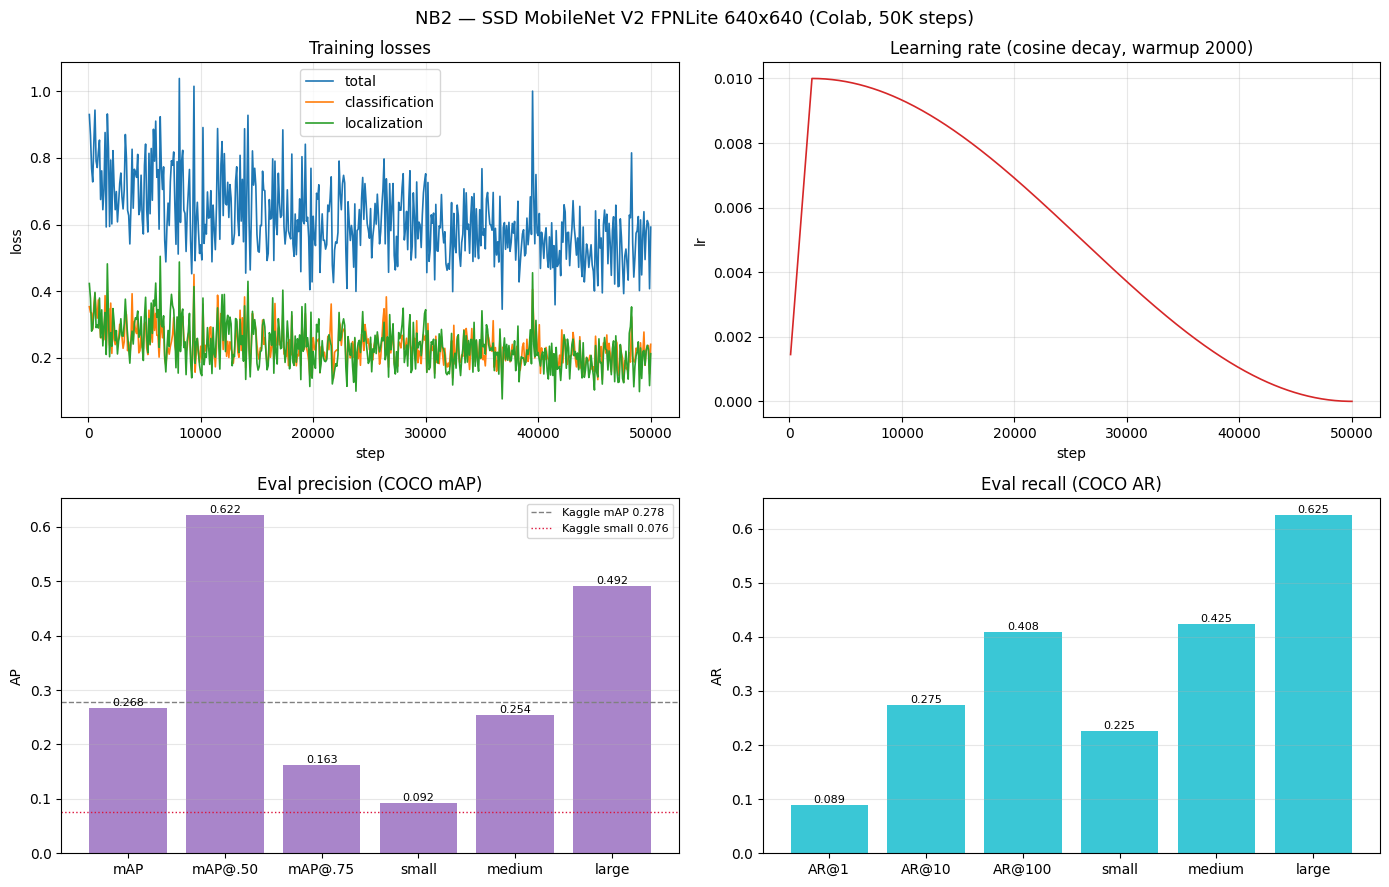

Saved figure to /content/nb2_training_curves.png


In [15]:
# Cell #16: Plot training curves + eval metrics. Runs in the KERNEL (Colab's
# Python 3.12 has matplotlib); only TF work goes to subprocess, and the series
# are already plain Python lists from Cell #15.

import matplotlib.pyplot as plt

def xy(series, tag):
    pts = series.get(tag, [])
    return [p[0] for p in pts], [p[1] for p in pts]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("NB2 — SSD MobileNet V2 FPNLite 640x640 (Colab, 50K steps)", fontsize=13)

# (1) Losses vs step.
ax = axes[0, 0]
for tag, lbl, c in [('Loss/total_loss', 'total', 'tab:blue'),
                    ('Loss/classification_loss', 'classification', 'tab:orange'),
                    ('Loss/localization_loss', 'localization', 'tab:green')]:
    x, y = xy(train_series, tag)
    if x:
        ax.plot(x, y, label=lbl, color=c, linewidth=1.2)
ax.set_title("Training losses")
ax.set_xlabel("step"); ax.set_ylabel("loss")
ax.legend(); ax.grid(True, alpha=0.3)

# (2) Learning rate vs step.
ax = axes[0, 1]
x, y = xy(train_series, 'learning_rate')
if x:
    ax.plot(x, y, color='tab:red', linewidth=1.2)
ax.set_title("Learning rate (cosine decay, warmup 2000)")
ax.set_xlabel("step"); ax.set_ylabel("lr"); ax.grid(True, alpha=0.3)

# (3) Precision/mAP eval metrics bar chart.
ax = axes[1, 0]
prec = [('mAP', 'DetectionBoxes_Precision/mAP'),
        ('mAP@.50', 'DetectionBoxes_Precision/mAP@.50IOU'),
        ('mAP@.75', 'DetectionBoxes_Precision/mAP@.75IOU'),
        ('small', 'DetectionBoxes_Precision/mAP (small)'),
        ('medium', 'DetectionBoxes_Precision/mAP (medium)'),
        ('large', 'DetectionBoxes_Precision/mAP (large)')]
labels = [l for l, _ in prec]
vals = [eval_series[t][-1][1] if t in eval_series and eval_series[t] else 0.0 for _, t in prec]
bars = ax.bar(labels, vals, color='tab:purple', alpha=0.8)
ax.bar_label(bars, fmt='%.3f', fontsize=8)
ax.axhline(0.278, ls='--', c='gray', lw=1, label='Kaggle mAP 0.278')
ax.axhline(0.076, ls=':', c='crimson', lw=1, label='Kaggle small 0.076')
ax.set_title("Eval precision (COCO mAP)")
ax.set_ylabel("AP"); ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

# (4) Recall (AR) eval metrics bar chart.
ax = axes[1, 1]
rec = [('AR@1', 'DetectionBoxes_Recall/AR@1'),
       ('AR@10', 'DetectionBoxes_Recall/AR@10'),
       ('AR@100', 'DetectionBoxes_Recall/AR@100'),
       ('small', 'DetectionBoxes_Recall/AR@100 (small)'),
       ('medium', 'DetectionBoxes_Recall/AR@100 (medium)'),
       ('large', 'DetectionBoxes_Recall/AR@100 (large)')]
labels = [l for l, _ in rec]
vals = [eval_series[t][-1][1] if t in eval_series and eval_series[t] else 0.0 for _, t in rec]
bars = ax.bar(labels, vals, color='tab:cyan', alpha=0.85)
ax.bar_label(bars, fmt='%.3f', fontsize=8)
ax.set_title("Eval recall (COCO AR)")
ax.set_ylabel("AR"); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/nb2_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved figure to /content/nb2_training_curves.png")

## 9. Save to Google Drive

In [16]:
# Cell #17: Copy the final checkpoint + config + metrics figure to Google Drive.
#
# /content is wiped when the Colab VM recycles, so persist the deliverables.
# We copy the latest checkpoint (the prefix the 'checkpoint' file points to),
# its .index/.data shards, pipeline.config, and the curves PNG.

import os, glob, json, shutil
from google.colab import drive

drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/SmartSpotter/NB2_colab"
os.makedirs(DRIVE_DIR, exist_ok=True)

# Resolve the latest checkpoint prefix from the 'checkpoint' pointer file.
latest_prefix = None
ckpt_file = os.path.join(TRAIN_DIR, "checkpoint")
if os.path.exists(ckpt_file):
    with open(ckpt_file) as f:
        first = f.readline().strip()
    # Line looks like: model_checkpoint_path: "ckpt-50"
    latest_prefix = first.split('"')[1] if '"' in first else None

copied = []
if latest_prefix:
    for p in glob.glob(os.path.join(TRAIN_DIR, latest_prefix + ".*")):
        dst = os.path.join(DRIVE_DIR, os.path.basename(p))
        shutil.copy2(p, dst); copied.append(dst)
    # Copy the pointer file too so the checkpoint is loadable standalone.
    shutil.copy2(ckpt_file, os.path.join(DRIVE_DIR, "checkpoint")); copied.append("checkpoint")

# pipeline.config + curves figure.
for src in [PIPELINE_CONFIG_PATH, "/content/nb2_training_curves.png"]:
    if os.path.exists(src):
        dst = os.path.join(DRIVE_DIR, os.path.basename(src))
        shutil.copy2(src, dst); copied.append(dst)

# Dump the eval metrics as JSON for the report / NB4 comparison.
metrics = {tag: eval_series[tag][-1][1]
           for tag in eval_series if eval_series[tag]}
with open(os.path.join(DRIVE_DIR, "nb2_eval_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
copied.append("nb2_eval_metrics.json")

print(f">> Saved to {DRIVE_DIR}:")
for c in copied:
    print(f"   {os.path.basename(c)}")
print(f"\nLatest checkpoint: {latest_prefix}")

ValueError: mount failed

In [1]:
import os, glob
TRAIN_DIR = "/content/nb2_run/training_output"
print("Exists:", os.path.isdir(TRAIN_DIR))
print(sorted(glob.glob(os.path.join(TRAIN_DIR, "ckpt-*.index"))))
print(open(os.path.join(TRAIN_DIR, "checkpoint")).read() if os.path.exists(os.path.join(TRAIN_DIR,"checkpoint")) else "no checkpoint file")

Exists: False
[]
no checkpoint file
